In [2]:
!pip install yfinance


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [4]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

C:\Users\Ravindra\AppData\Local\Temp\ipykernel_16268\3729526159.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600
2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200
2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400
2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200
2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200
...,...,...,...,...,...
2025-08-26,229.309998,229.490005,224.690002,226.869995,54575100
2025-08-27,230.490005,230.899994,228.259995,228.610001,31259500


# 2. Data Exploration & Visualization

In [5]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600
2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200
2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400
2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200
2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200
...,...,...,...,...,...
2025-08-26,229.309998,229.490005,224.690002,226.869995,54575100
2025-08-27,230.490005,230.899994,228.259995,228.610001,31259500


In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.shape

(2513, 5)

In [8]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [9]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,106.520358,107.586656,105.342641,106.418111,1.063100e+08
std,69.642124,70.323293,68.876695,69.566195,5.989446e+07
min,20.624046,20.927678,20.425432,20.546428,2.323470e+07
25%,40.165329,40.584931,39.778311,40.154912,6.532520e+07
50%,109.926819,112.164080,108.068936,110.685565,9.222970e+07
75%,167.616318,169.158706,166.090056,167.596472,1.299300e+08
max,258.103729,259.179926,256.718662,257.276679,5.334788e+08


In [10]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [11]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600
2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200
2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400
2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200
2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200


In [12]:
df = df.reset_index()

In [13]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600
1,2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200
2,2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400
3,2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200
4,2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200


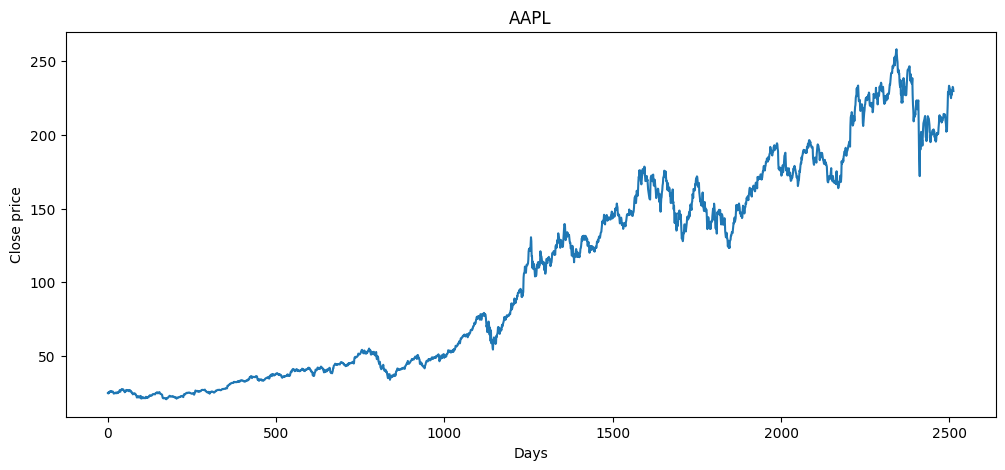

In [14]:
plt.figure(figsize = (12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price');

# 3. Feature Engineering

In [15]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[:5])/5)

30.0


In [16]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [17]:
df1['MA_5'] = df1.rolling(5).mean() # used to calculate the moving average (rolling)
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 days Moving Average

In [18]:
df.columns = df.columns.droplevel(1) 

In [19]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
0,2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600,NaN
1,2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200,NaN
2,2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400,NaN
3,2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200,NaN
4,2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200,NaN


In [20]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
0,2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600,NaN
1,2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200,NaN
2,2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400,NaN
3,2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200,NaN
4,2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200,NaN
...,...,...,...,...,...,...,...
98,2016-01-26,22.566492,22.767354,22.133173,22.552951,300308000,NaN
99,2016-01-27,21.083725,21.808182,21.065670,21.675027,533478800,25.099210
100,2016-01-28,21.234934,21.331980,20.851266,21.167229,222715200,25.063530
101,2016-01-29,21.968418,21.968418,21.293613,21.392916,257666000,25.037656


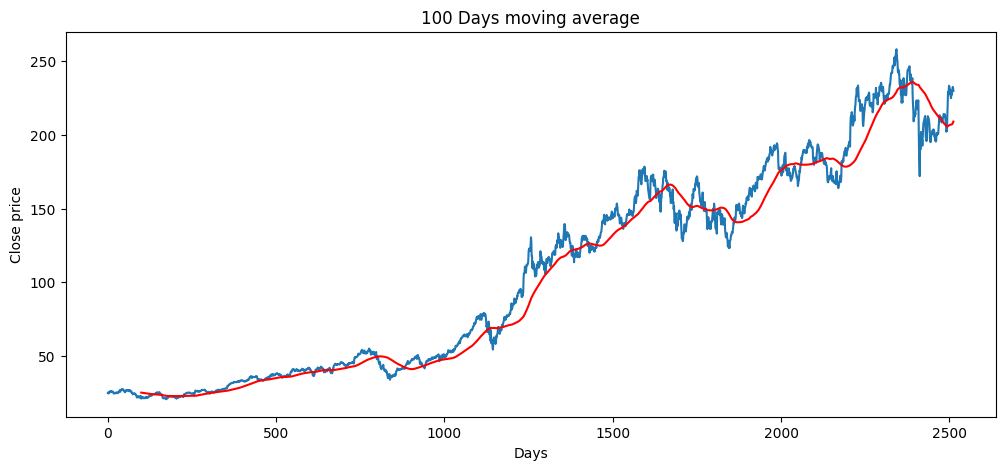

In [21]:
plt.figure(figsize = (12, 5))
plt.plot(df.Close)
plt.title('100 Days moving average')
plt.xlabel('Days')
plt.ylabel('Close price')
plt.plot(df['MA_100'], 'r')

In [22]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
0,2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600,NaN,NaN
1,2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200,NaN,NaN
2,2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400,NaN,NaN
3,2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200,NaN,NaN
4,2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2016-06-17,21.763233,22.064581,21.756385,22.057732,244032800,22.733735,NaN
199,2016-06-20,21.710728,22.046320,21.694747,21.916192,137647600,22.740005,23.919608
200,2016-06-21,21.895651,21.996099,21.614849,21.674206,142185600,22.746612,23.905071
201,2016-06-22,21.813457,22.119370,21.767798,21.973262,116876400,22.745063,23.891359


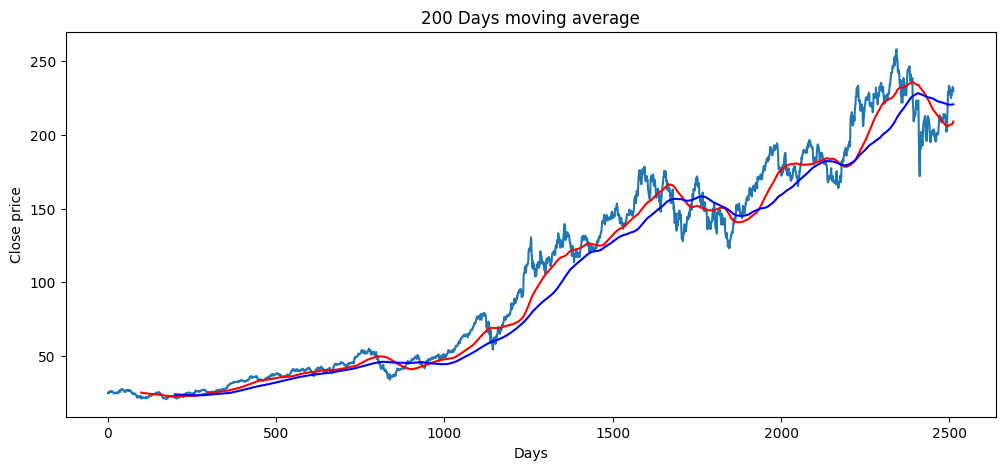

In [23]:
plt.figure(figsize = (12, 5))
plt.plot(df.Close)
plt.title('200 Days moving average')
plt.xlabel('Days')
plt.ylabel('Close price')
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'b')

In [24]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
0,2015-09-03,24.802959,25.344547,24.728800,25.279377,212935600,NaN,NaN
1,2015-09-04,24.555761,24.820938,24.384971,24.488345,199985200,NaN,NaN
2,2015-09-08,25.238920,25.295102,24.791717,25.113074,219374400,NaN,NaN
3,2015-09-09,24.753525,25.623212,24.668128,25.564784,340043200,NaN,NaN
4,2015-09-10,25.297359,25.456914,24.697343,24.780490,251571200,NaN,NaN
...,...,...,...,...,...,...,...,...
2508,2025-08-26,229.309998,229.490005,224.690002,226.869995,54575100,207.172082,220.569821
2509,2025-08-27,230.490005,230.899994,228.259995,228.610001,31259500,207.450044,220.613830
2510,2025-08-28,232.559998,233.410004,229.339996,230.820007,38074700,207.896444,220.644499
2511,2025-08-29,232.139999,233.380005,231.369995,232.509995,39418400,208.407674,220.674413


### Calculating % changed in each trading session

In [25]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
0,24.802959,NaN
1,24.555761,-0.009966
2,25.238920,0.027821
3,24.753525,-0.019232
4,25.297359,0.021970
...,...,...
2508,229.309998,0.009465
2509,230.490005,0.005146
2510,232.559998,0.008981
2511,232.139999,-0.001806


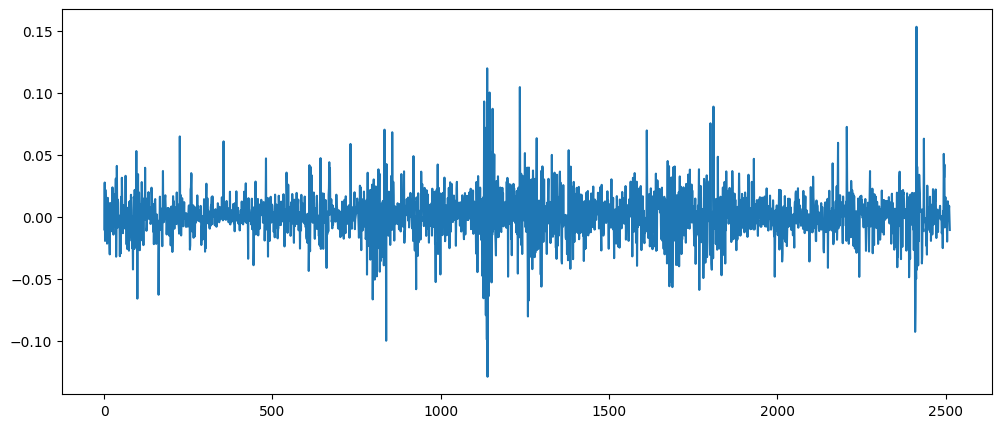

In [26]:
plt.figure(figsize = (12, 5))
plt.plot(df['Percentage Changed'])

# 4. Data Preprocessing

In [27]:
df.shape

(2513, 9)

In [28]:
# Splitting data into Training & Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])

print(data_training)
print(data_testing)

           Close
0      24.802959
1      24.555761
2      25.238920
3      24.753525
4      25.297359
...          ...
1754  164.631241
1755  164.926559
1756  167.387756
1757  161.077301
1758  158.872147

[1759 rows x 1 columns]
           Close
1759  156.440521
1760  154.776749
1761  155.505310
1762  153.388687
1763  152.128601
...          ...
2508  229.309998
2509  230.490005
2510  232.559998
2511  232.139999
2512  229.720001

[754 rows x 1 columns]


In [29]:
# Scaling down the data between 0 and 1

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [31]:
data_training_array = scaler.fit_transform(data_training)

In [32]:
data_training_array

array([[0.02647914],
       [0.0249128 ],
       [0.02924155],
       ...,
       [0.92994907],
       [0.88996369],
       [0.87599102]])

In [33]:
data_training_array.shape

(1759, 1)

# 5. Sequence Creation

In [37]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100 : i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [38]:
x_train

array([[[0.02647914],
        [0.0249128 ],
        [0.02924155],
        ...,
        [0.01152152],
        [0.01230805],
        [0.00291269]],

       [[0.0249128 ],
        [0.02924155],
        [0.0261659 ],
        ...,
        [0.01230805],
        [0.00291269],
        [0.00387081]],

       [[0.02924155],
        [0.0261659 ],
        [0.02961184],
        ...,
        [0.00291269],
        [0.00387081],
        [0.00851844]],

       ...,

       [[0.9535456 ],
        [0.97923489],
        [0.95821086],
        ...,
        [0.91460356],
        [0.91248277],
        [0.91435401]],

       [[0.97923489],
        [0.95821086],
        [0.93811994],
        ...,
        [0.91248277],
        [0.91435401],
        [0.92994907]],

       [[0.95821086],
        [0.93811994],
        [0.94004814],
        ...,
        [0.91435401],
        [0.92994907],
        [0.88996369]]])

In [39]:
x_train.ndim

3

In [40]:
y_train.ndim

1

In [41]:
x_train.shape

(1659, 100, 1)

In [42]:
y_train.shape

(1659,)

In [43]:
x_train.ndim

3

# 6. Model Building

In [44]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [45]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input


In [46]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units = 128, activation = 'tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [49]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 0.0444
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 6.3900e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 5.7840e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 4.9369e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 5.0588e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 5.6694e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 6.0927e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 5.0352e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 4.5160e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 5.0631e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 4.7123e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 3.5993e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 4.5551e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 4.2453e-04
Epoch 15/50
52/5

In [50]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [51]:
# Save the trained Model
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [53]:
data_training

,Close
0,24.802959
1,24.555761
2,25.238920
3,24.753525
4,25.297359
...,...
1754,164.631241
1755,164.926559
1756,167.387756
1757,161.077301


In [54]:
data_testing

,Close
1759,156.440521
1760,154.776749
1761,155.505310
1762,153.388687
1763,152.128601
...,...
2508,229.309998
2509,230.490005
2510,232.559998
2511,232.139999


In [55]:
past_100_days = data_training.tail(100)

In [56]:
past_100_days

,Close
1659,168.677277
1660,168.981583
1661,166.969208
1662,162.708786
1663,164.583801
...,...
1754,164.631241
1755,164.926559
1756,167.387756
1757,161.077301


In [57]:
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)
final_df

,Close
0,168.677277
1,168.981583
2,166.969208
3,162.708786
4,164.583801
...,...
849,229.309998
850,230.490005
851,232.559998
852,232.139999


In [58]:
input_data = scaler.fit_transform(final_df)
input_data

array([[3.36709213e-01],
       [3.38966302e-01],
       [3.24040184e-01],
       [2.92439932e-01],
       [3.06347230e-01],
       [3.26297159e-01],
       [2.89090686e-01],
       [2.87489119e-01],
       [3.04454006e-01],
       [3.03216303e-01],
       [2.97318651e-01],
       [2.63607195e-01],
       [2.71543617e-01],
       [2.27274448e-01],
       [2.25600108e-01],
       [2.77076951e-01],
       [2.33463304e-01],
       [2.35720732e-01],
       [2.46787967e-01],
       [2.94406155e-01],
       [2.27056130e-01],
       [2.32452068e-01],
       [1.94388958e-01],
       [2.12253715e-01],
       [1.53846593e-01],
       [1.25117188e-01],
       [1.58294674e-01],
       [1.46846712e-01],
       [1.73826175e-01],
       [1.12429484e-01],
       [8.71270770e-02],
       [8.88771323e-02],
       [1.29127840e-01],
       [1.09075259e-01],
       [1.10242000e-01],
       [1.34013010e-01],
       [1.76742972e-01],
       [1.70909379e-01],
       [1.69961635e-01],
       [1.88190935e-01],


In [59]:
input_data.shape

(854, 1)

In [60]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [61]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [62]:
x_test

array([[[0.33670921],
        [0.3389663 ],
        [0.32404018],
        ...,
        [0.32714463],
        [0.28033894],
        [0.26398294]],

       [[0.3389663 ],
        [0.32404018],
        [0.29243993],
        ...,
        [0.28033894],
        [0.26398294],
        [0.24594718]],

       [[0.32404018],
        [0.29243993],
        [0.30634723],
        ...,
        [0.26398294],
        [0.24594718],
        [0.2336067 ]],

       ...,

       [[0.47943589],
        [0.4282344 ],
        [0.36134682],
        ...,
        [0.77048527],
        [0.78643213],
        [0.79518444]],

       [[0.4282344 ],
        [0.36134682],
        [0.55690393],
        ...,
        [0.78643213],
        [0.79518444],
        [0.81053792]],

       [[0.36134682],
        [0.55690393],
        [0.49452985],
        ...,
        [0.79518444],
        [0.81053792],
        [0.80742272]]])

# 9. Making Predictions

In [63]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [64]:
y_test

array([2.45947175e-01, 2.33606699e-01, 2.39010559e-01, 2.23311217e-01,
       2.13964951e-01, 2.24406544e-01, 2.13453843e-01, 2.34702252e-01,
       2.78951728e-01, 2.08926539e-01, 2.19660468e-01, 1.98192722e-01,
       1.85998584e-01, 2.13599615e-01, 2.31270161e-01, 2.08050323e-01,
       2.00894256e-01, 1.84027154e-01, 1.86509917e-01, 1.93738643e-01,
       1.79718847e-01, 1.25976993e-01, 9.47247596e-02, 1.25757656e-01,
       1.52409812e-01, 1.54600465e-01, 1.47517398e-01, 1.08525558e-01,
       1.10934756e-01, 1.00420277e-01, 9.57469739e-02, 1.29700968e-01,
       9.60390836e-02, 1.25465886e-01, 1.35250487e-01, 1.36053591e-01,
       1.32621612e-01, 1.60953088e-01, 1.76871088e-01, 1.97973499e-01,
       1.76140870e-01, 1.42917321e-01, 2.22800336e-01, 2.05275450e-01,
       1.85633362e-01, 1.44596867e-01, 9.96900592e-02, 9.77152344e-02,
       1.01664771e-01, 1.05906983e-01, 7.20429647e-02, 1.59811246e-01,
       1.80509954e-01, 1.70124044e-01, 1.82996565e-01, 1.73854130e-01,
      

In [65]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [66]:
y_predicted

array([163.33788 , 160.81744 , 158.51234 , 157.27026 , 156.05693 ,
       154.85297 , 154.48106 , 154.0023  , 154.55682 , 157.21036 ,
       156.55759 , 155.59964 , 153.8762  , 151.9477  , 151.70103 ,
       152.81241 , 153.05307 , 152.66377 , 151.48325 , 150.51631 ,
       150.19707 , 149.6065  , 146.9684  , 143.30872 , 141.50725 ,
       141.79836 , 142.84041 , 143.59918 , 142.56093 , 141.29187 ,
       139.88817 , 138.64386 , 139.0075  , 138.62454 , 139.15108 ,
       140.2217  , 141.2299  , 141.80804 , 143.15039 , 145.00565 ,
       147.36589 , 148.32375 , 147.1963  , 148.94078 , 150.38766 ,
       150.51552 , 148.517   , 144.72757 , 141.43053 , 139.34427 ,
       138.38728 , 136.89105 , 138.73346 , 142.14726 , 144.81975 ,
       146.97203 , 147.91759 , 148.72542 , 149.39085 , 148.81888 ,
       148.6717  , 148.96626 , 148.44986 , 146.71512 , 144.25848 ,
       144.19429 , 145.03387 , 145.82603 , 146.04256 , 144.93677 ,
       143.16101 , 142.12228 , 141.47519 , 141.78236 , 142.612

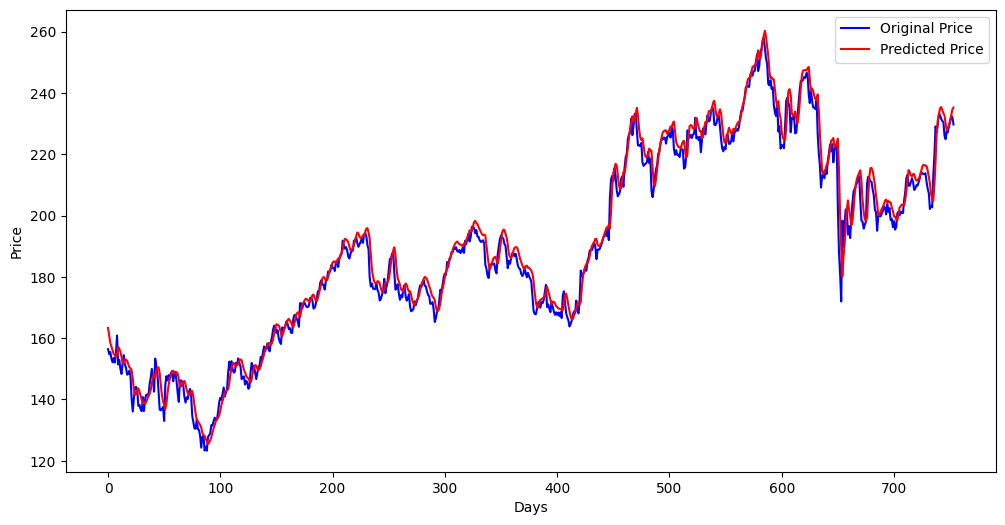

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label= 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

# 10. Model Evaluation

In [75]:
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [71]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 18.745209609170153


In [72]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.329573836900135


In [76]:
# R-Squared 
r2 = r2_score(y_test,y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9810657355448301
